# Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/AAI/blob/main/courses/Machine_Learning/exercises/05/03_classification.ipynb)
- Dataset: [`sklearn.datasets.load_iris()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)

---

Despite the word **regression** in its name, [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) is one of the most widely used **classifiers** in machine learning.

Botanists have measured iris flowers for centuries. Can a model tell **setosa**, **versicolor**, and **virginica** apart using only two measurements at a time?

In this exercise you will:

- Load and explore the classic Iris dataset
- Meet **`LogisticRegression`** for the first time — what it predicts, and how it draws decision boundaries
- Compare two feature pairs (sepal vs petal) and see which separates species better
- Visualize learned boundaries with **`DecisionBoundaryDisplay`**

**How this exercise works:** before each code cell, pause and write down what you **expect** to see. Then run the cell and compare.


![Iris Flowers](../../assets/iris_flowers.png)

## What is Logistic Regression?

Logistic regression models the **probability** that a sample belongs to each class.

- It starts with a **linear combination** of features (like linear regression).
- That score is passed through a **logistic / softmax** function so outputs lie between 0 and 1 and sum to 1 across classes.
- The model learns coefficients that place a **linear decision boundary** between classes.
- **`predict`** returns the most likely class label; **`predict_proba`** returns the full probability vector.

> **Surprising but true:** the name says "regression" because the algorithm originally modeled the *log-odds* of a binary outcome — a regression target — even though we use it for classification today.

Full API reference: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)


## Setup

In [1]:
# https://matplotlib.org/stable/
import matplotlib.pyplot as plt

# https://pandas.pydata.org/docs/
import pandas as pd

# https://seaborn.pydata.org/
import seaborn as sns

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
from sklearn.datasets import load_iris

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
from sklearn.linear_model import LogisticRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html
from sklearn.inspection import DecisionBoundaryDisplay

RANDOM_STATE = 42  # reproducible splits and models


## Step 1 — Load the data

The Iris dataset ships with scikit-learn — 150 samples, 4 numeric features, 3 species.

Load it with `as_frame=True` so features and target come back as pandas objects.


### Step 1.a Load the data

In [2]:
iris = load_iris(as_frame=True)


## Step 2 — Features and target

Assign **`X`** to the feature matrix and **`y`** to the target.

Then inspect their types and decide: is this a **regression** or **classification** task?

**Predict:** will `y` be numeric measurements or discrete class labels?


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data
y = iris.target


### Step 2.b Print the type of each

In [4]:
display(X.dtypes)
display(y.dtype)


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

dtype('int64')

### Step 2.c Identify whether the target is categorical or numerical, and whether the task is regression or classification

Write your answer in a markdown cell or your notes:

- Target type: …
- Task type: …


## Step 3 — Dataset shape

How many samples and columns does each of `X` and `y` have?


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [5]:
print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (150, 4)
y shape: (150,)


## Step 4 — Summary statistics

Summarize the distribution of the features (min, max, median, mean, standard deviation).

**Predict:** will all four features be on a similar numeric scale?


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [6]:
display(X.describe())
display(y.describe())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


count    150.000000
mean       1.000000
std        0.819232
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: target, dtype: float64

## Step 5 — Visual separability

Plot two scatter views side by side:

1. **Sepal** length vs sepal width
2. **Petal** length vs petal width

Map integer targets to species names (`setosa`, `versicolor`, `virginica`) for readable legends.

**Predict:** which pair of features will show the clearest, non-overlapping clusters?


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


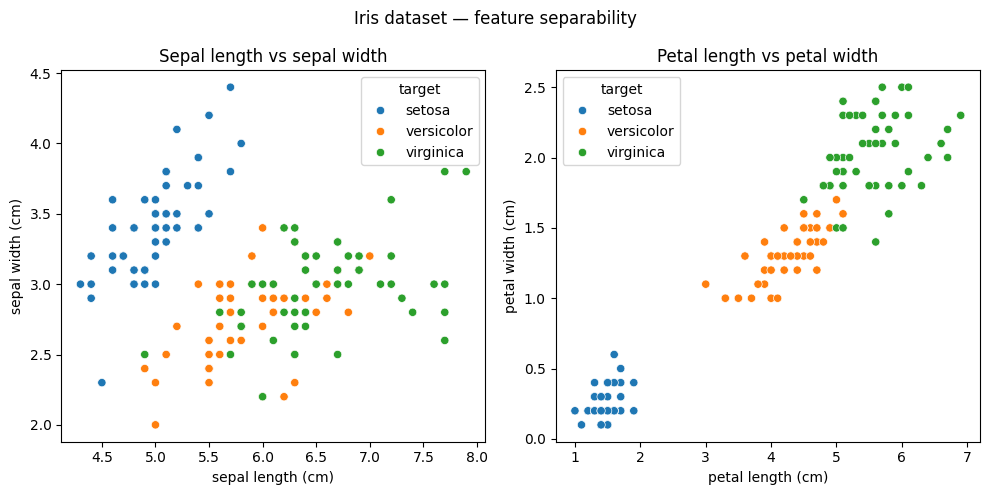

In [7]:
full_df = pd.concat([X, y], axis=1)

# Map integer codes to species names for readable plots
species_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
full_df['target'] = full_df['target'].map(species_names)

display(full_df.head())

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

sns.scatterplot(
    data=full_df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='target',
    ax=axes[0],
)
axes[0].set_title('Sepal length vs sepal width')

sns.scatterplot(
    data=full_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    ax=axes[1],
)
axes[1].set_title('Petal length vs petal width')

fig.suptitle('Iris dataset — feature separability')
fig.tight_layout()
plt.show()


## Step 6 — Two feature subsets

From here on we train **two** `LogisticRegression` models:

1. **Sepal model** — `sepal length (cm)` and `sepal width (cm)`
2. **Petal model** — `petal length (cm)` and `petal width (cm)`

We will evaluate which feature set scores better on held-out data.


### Step 6.a Subset the features `sepal length (cm)` and `sepal width (cm)`

In [8]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]


### Step 6.b Subset the features `petal length (cm)` and `petal width (cm)`

In [9]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]


## Step 7 — Initialize two classifiers

Create one `LogisticRegression` instance per feature subset.

**Predict:** will the two models share the same hyperparameters by default?


### Step 7. Initialize 2 `LogisticRegression` models

In [10]:
lr_sepal = LogisticRegression(random_state=RANDOM_STATE)
lr_petal = LogisticRegression(random_state=RANDOM_STATE)


## Step 8 — Stratified train-test split

Split each feature subset into train and test sets.

- Use `test_size=0.20` and `random_state=RANDOM_STATE`.
- Pass **`stratify=y`** so each split keeps the same class proportions as the full dataset.

Iris is balanced (50 flowers per species), but stratifying is good practice — especially on imbalanced datasets you will meet later.


### Step 8. Split the dataset into train and test sets (remember to stratify by the target)

In [11]:
X_sepal_train, X_sepal_test, y_sepal_train, y_sepal_test = train_test_split(
    X_sepal,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,  # preserve class proportions in train and test
)

X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)


## Step 9 — Train both models

### Step 9.a Train both models

In [12]:
lr_sepal.fit(X_sepal_train, y_sepal_train)
lr_petal.fit(X_petal_train, y_petal_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

## Step 10 — Evaluate and compare

Use each model's **`.score(X_test, y_test)`** method (accuracy on the test set).

Then explore probabilities: pick one test row and call **`predict_proba`**. Which species does the model think is most likely, and with what confidence?


### Step 10. Evaluate and compare both models

In [13]:
score_sepal = lr_sepal.score(X_sepal_test, y_sepal_test)
score_petal = lr_petal.score(X_petal_test, y_petal_test)

comparison = pd.Series(
    {
        'sepal features': score_sepal,
        'petal features': score_petal,
    },
    name='test accuracy',
)
comparison.round(3)


sepal features    0.733
petal features    0.967
Name: test accuracy, dtype: float64

### Step 10.b Explore `predict_proba` on one test sample

In [14]:
sample_idx = 0
sample_row = X_petal_test.iloc[[sample_idx]]
true_label = y_petal_test.iloc[sample_idx]

proba = lr_petal.predict_proba(sample_row)[0]
proba_df = pd.DataFrame(
    {
        'species_code': lr_petal.classes_,
        'probability': proba,
    }
).sort_values('probability', ascending=False)

print(f'True label (integer code): {true_label}')
print(f'Predicted label: {lr_petal.predict(sample_row)[0]}')
proba_df


True label (integer code): 0
Predicted label: 0


,species_code,probability
0,0,9.827288e-01
1,1,1.727109e-02
2,2,6.624494e-08


## Step 11 — Which features win?

Compare the two test scores.

- Which feature subset performed better?
- Does that match what you saw in the Step 5 scatter plots?
- Why might petal measurements separate species more cleanly than sepal measurements?


### Step 11. Which of the two subsets of features better distinguishes iris flowers? Can you easily tell?

In [15]:
print(f'Score of sepal model: {score_sepal:.3f}')
print(f'Score of petal model: {score_petal:.3f}')

if score_petal > score_sepal:
    print('Petal features separate species more effectively.')
else:
    print('Sepal features scored higher on this split — inspect the plots to see why.')


Score of sepal model: 0.733
Score of petal model: 0.967
Petal features separate species more effectively.


## Step 12 — Decision boundaries

`LogisticRegression` learns **linear** boundaries. Overlay them on the scatter plots with [`DecisionBoundaryDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html).

**Predict:** will the boundary lines be straight or curved?


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

/home/halgoz/work/Bootcamp/ai-pros/public/.venv/lib/python3.12/site-packages/sklearn/inspection/_plot/decision_boundary.py:392: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case.
  warnings.warn(
/home/halgoz/work/Bootcamp/ai-pros/public/.venv/lib/python3.12/site-packages/sklearn/inspection/_plot/decision_boundary.py:392: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case.
  warnings.warn(


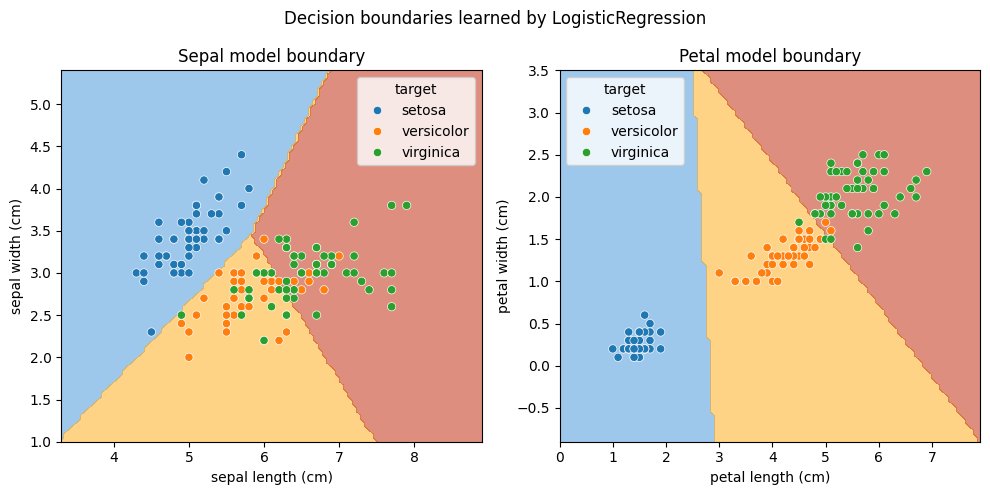

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

DecisionBoundaryDisplay.from_estimator(
    lr_sepal,
    X_sepal,
    response_method='predict',
    cmap='RdBu_r',
    alpha=0.5,
    ax=axes[0],
)
sns.scatterplot(
    data=full_df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='target',
    ax=axes[0],
)
axes[0].set_title('Sepal model boundary')

DecisionBoundaryDisplay.from_estimator(
    lr_petal,
    X_petal,
    response_method='predict',
    cmap='RdBu_r',
    alpha=0.5,
    ax=axes[1],
)
sns.scatterplot(
    data=full_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    ax=axes[1],
)
axes[1].set_title('Petal model boundary')

fig.suptitle('Decision boundaries learned by LogisticRegression')
fig.tight_layout()
plt.show()


## Explore further

Optional stretch goals — try these if you have time:

1. Train on **all four** features. Does accuracy beat the two-feature models?
2. Train on **one feature at a time** (`petal length` only, then `petal width` only). How close can a single measurement get?
3. Plot a KDE of `petal width (cm)` by species. Where do the distributions overlap?


### Explore 1 — All four features

In [17]:
X_all = X[
    [
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)',
    ]
]

lr_all = LogisticRegression(random_state=RANDOM_STATE)
lr_all.fit(X_all, y)
score_all = lr_all.score(X_all, y)
print(f'Accuracy with all four features (trained on full data): {score_all:.3f}')


Accuracy with all four features (trained on full data): 0.973


/home/halgoz/work/Bootcamp/ai-pros/public/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Explore 2 — Single-feature models

In [18]:
for feature in ['petal length (cm)', 'petal width (cm)']:
    lr_one = LogisticRegression(random_state=RANDOM_STATE)
    lr_one.fit(X[[feature]], y)
    score_one = lr_one.score(X[[feature]], y)
    print(f'{feature}: accuracy = {score_one:.3f}')


petal length (cm): accuracy = 0.953
petal width (cm): accuracy = 0.960


### Explore 3 — Distribution overlap on petal width

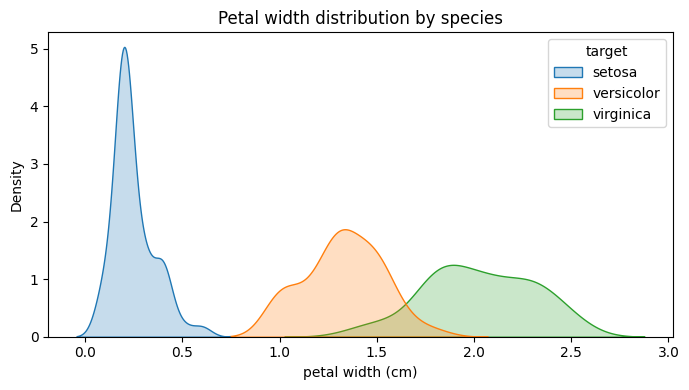

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.kdeplot(
    data=full_df,
    x='petal width (cm)',
    hue='target',
    fill=True,
    common_norm=False,
    ax=ax,
)
ax.set_title('Petal width distribution by species')
fig.tight_layout()
plt.show()


---

## Wrap-up — Reflect

Answer in a markdown cell or your notes:

1. **Probabilities vs labels:** What extra information does `predict_proba` give you that `predict` alone does not?
2. **Feature choice:** Why did petal measurements outperform sepal measurements for this dataset?
3. **Linear boundaries:** Where might `LogisticRegression` struggle — even on Iris?
4. **Next steps:** You used accuracy (`.score`). What other metrics from the model-evaluation lessons would you check before deploying a classifier?

**Key takeaway:** `LogisticRegression` is a fast, interpretable baseline classifier. Exploring features *before* modeling — and visualizing boundaries *after* — helps you trust (or question) the numbers.
